In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **PREPROCESS DATA**

In [53]:
import tensorflow as tf

# Paths
train_dir = "/kaggle/input/cat-and-dog/training_set/training_set"  
test_dir = "/kaggle/input/cat-and-dog/test_set/test_set"

# Image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Function to decode and normalize images
def process(image, label):
     # resize
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH]) 
    # normalize 
    image = tf.cast(image / 255., tf.float32)                
    return image, label

# load dataset from folder 
def load_dataset(data_dir):
    return tf.keras.preprocessing.image_dataset_from_directory(
        data_dir,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        # unbatch first to map functions
        batch_size=None, 
         # binary labels (0/1)
        label_mode='binary',     
        shuffle=True
    )

# Load datasets
train_ds = load_dataset(train_dir)
test_ds = load_dataset(test_dir)

# Apply normalization
train_ds = train_ds.map(process, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(process, num_parallel_calls=AUTOTUNE)

# Shuffle, batch, and prefetch
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Optional: check a batch
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)


Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32, 1)


# MODEL
> Conv2D(32) → MaxPooling → Conv2D(64) → MaxPooling → Flatten → Dense(128) → Output
 

In [54]:


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import HeNormal, GlorotUniform
from tensorflow.keras.regularizers import l2 

# CNN model

In [55]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

he_init = HeNormal()
model = Sequential([
    Conv2D(32, (3,3), activation='relu', kernel_initializer=he_init, kernel_regularizer=l2(0.001),
           input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', kernel_initializer=he_init,kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', kernel_initializer=he_init,kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu', kernel_initializer=he_init),
    Dropout(0.6),
    Dense(1, activation='sigmoid', kernel_initializer=GlorotUniform())
])

# **learning** 

In [56]:
model.compile(
    optimizer=Adam(learning_rate=0.0008),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# safer training 

In [57]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)


In [58]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

# Train the model

In [59]:
history = model.fit(
    train_ds,                
    validation_data=test_ds, 
    epochs=20,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.5829 - loss: 1.9530 - val_accuracy: 0.5180 - val_loss: 1.1876
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6803 - loss: 0.9890 - val_accuracy: 0.7009 - val_loss: 0.9182
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7368 - loss: 0.8536 - val_accuracy: 0.7138 - val_loss: 0.8356
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7670 - loss: 0.7808 - val_accuracy: 0.7860 - val_loss: 0.7481
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7817 - loss: 0.7147 - val_accuracy: 0.7924 - val_loss: 0.6792
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7975 - loss: 0.6549 - val_accuracy: 0.7850 - val_loss: 0.6763
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7667 - loss: 0.7821 - val_accuracy: 0.8018 - val_loss: 0.6635
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8298 - loss: 0.5748 - val_acc

In [60]:
model.save('final_model.keras') 

# plots

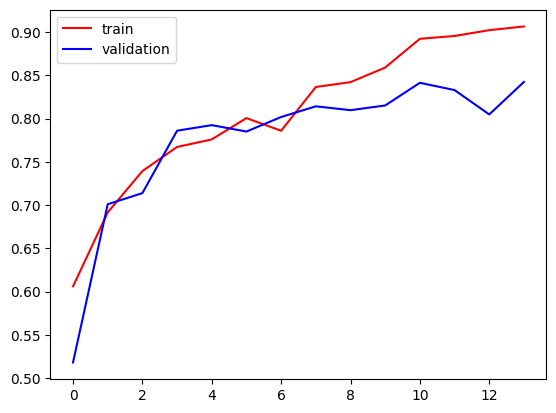

In [61]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

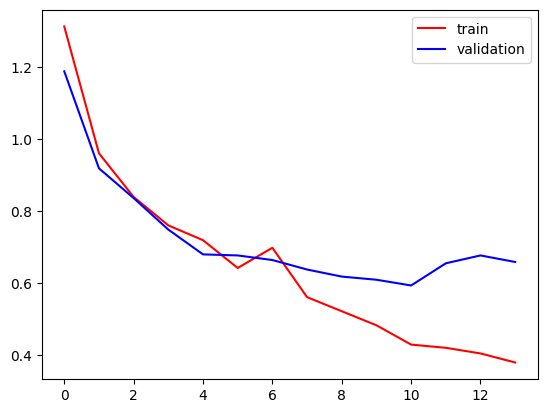

In [62]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()